# Setup

In [1]:
# %pip install git+https://github.com/facebookresearch/segment-anything.git
# %pip install numpy==1.26.4 matplotlib opencv-python pillow tqdm requests
# %pip install torch torchvision transformers
# %pip install open3d trimesh pyrender pyglet
# !git clone https://github.com/nv-nguyen/cnos.git

import torch
torch.set_num_threads(4)
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


# Editing cloned files

In [ ]:
trimesh_utils_path = "cnos/src/utils/trimesh_utils.py"

with open(trimesh_utils_path, "r") as f:
    lines = f.readlines()

with open(trimesh_utils_path, "w") as f:
    for line in lines:
        if "def get_obj_diameter(" in line:
            line = line.replace("mesh_path", "mesh")
        f.write(line)

print("✔️ Modified get_obj_diameter.")

In [2]:
import os

old_path = "cnos/src/poses/pyrender.py"
new_path = "cnos/src/poses/generate_views.py"

if os.path.exists(old_path):
    os.rename(old_path, new_path)
    print("✔️ Renamed pyrender.py to generate_views.py.")
else:
    print("✔️ generate_views.py already exists.")

✔️ generate_views.py already exists.


In [3]:
generate_views_path = "cnos/src/poses/generate_views.py"

# Standard
# insertion_code = '''\
# # === Added by user ===
# import sys
# import os
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "../..")))
# # =====================

# '''

# For Mac architecture
insertion_code = '''\
# === Added by user ===
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "../..")))
os.environ["PYOPENGL_PLATFORM"] = "pyglet"
import pyrender.platforms
pyrender.platforms.egl = None

from pyrender.offscreen import OffscreenRenderer
from pyrender.platforms.pyglet_platform import PygletPlatform
from pyrender.renderer import Renderer

def _safe_create(self):
    self._platform = PygletPlatform(self.viewport_width, self.viewport_height)
    self._platform.init_context()  # creates and activates the context
    self._renderer = Renderer(viewport_width=self.viewport_width,
                              viewport_height=self.viewport_height)

OffscreenRenderer._create = _safe_create
# =====================

'''

if os.path.exists(generate_views_path):
    with open(generate_views_path, "r") as f:
        original_code = f.read()
    if "# === Added by user ===" not in original_code:
        with open(generate_views_path, "w") as f:
            f.write(insertion_code + original_code)
        print("✔️ Custom code inserted at the top.")
    else:
        print("✔️ Custom code already inserted.")

✔️ Custom code already inserted.


In [9]:
import requests
import os
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch.nn as nn
import torchvision.transforms as T

# Load SAM ViT-H
SAM_CHECKPOINT = "sam_vit_h_4b8939.pth"
if not os.path.exists(SAM_CHECKPOINT):
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
    r = requests.get(url, stream=True)
    with open(SAM_CHECKPOINT, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)

sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT).to(device)
mask_gen = SamAutomaticMaskGenerator(sam)

# Load Depth Anything V2 Large
print("Loading Depth Anything V2 Large...")
depth_processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Large-hf")
depth_model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Large-hf")
depth_model.to(device).eval()

# Load DINOV2 & Predator
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14').to(device).eval()
dinov2_transform = T.Compose([
    T.Resize((518, 518)), 
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class PredatorExtractor(nn.Module):
    def __init__(self, in_dim=3, feat_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, feat_dim), nn.ReLU(),
            nn.Linear(feat_dim, feat_dim)
        )
    def forward(self, x): 
        return self.mlp(x)

pred_extractor = PredatorExtractor().to(device).eval()

print("✔️ All models loaded successfully!")

/Users/arnav/Desktop/IITISOC/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Depth Anything V2 Large...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Using cache found in /Users/arnav/.cache/torch/hub/facebookresearch_dinov2_main
/Users/arnav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/arnav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/arnav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


✔️ All models loaded successfully!


# Get sample data

In [4]:
!curl -L -o model.ply "https://github.com/pitcher69/IITISOC/raw/refs/heads/main/DATA/mustard/model.ply"
!curl -L -o obj_000005.png "https://raw.githubusercontent.com/pitcher69/IITISOC/main/DATA/mustard/obj_000005.png"
print("✔️ Downloaded sample model and image.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0 0 --:--:-- --:--:-- --:--:--     0
100 1035k  100 1035k    0     0  1086k      0 --:--:-- --:--:-- --:--:-- 11.0M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6603k  100 6603k    0     0  4310k      0  0:00:01  0:00:01 --:--:-- 4310k
✔️ Downloaded sample model and image.


# Load and normalize model

In [5]:
import trimesh
import numpy as np

mesh = trimesh.load("model.ply")
print("Center (centroid):", mesh.centroid)
print("Bounding Box centre:",mesh.bounding_box.centroid)
mesh.show()

def normalize_model(model_path):
    mesh = trimesh.load_mesh(model_path)
    print(f"Original center: {mesh.bounding_box.centroid}")
    
    centroid = mesh.bounding_box.centroid
    mesh.apply_translation(-centroid)
    
    max_extent = np.max(mesh.bounding_box.extents)
    if max_extent == 0:
        raise ValueError("Mesh has zero size.")
    mesh.apply_scale(1.0 / max_extent)
    
    if mesh.visual.kind != 'vertex':
        mesh.visual.vertex_colors = np.tile([180, 180, 180, 255], (len(mesh.vertices), 1))
    
    base, ext = os.path.splitext(model_path)
    new_path = f"{base}_normal{ext}"
    mesh.export(new_path)
    print(f"Normalized and saved: {new_path}")

# Normalize the model
normalized_model = normalize_model("model.ply")

Center (centroid): [  0.26319123   0.35582166 -15.915011  ]
Bounding Box centre: [0. 0. 0.]
Original center: [0. 0. 0.]
Normalized and saved: model_normal.ply


In [6]:
"""
This script renders synthetic views of a 3D CAD model using Blender via CNOS.

Expected Command-Line Arguments:
--------------------------------
1. cad_path (str) [required]
   - Path to the normalized 3D CAD model file (.obj, .ply, etc.)
   - Example: /path/to/models/duck.obj

2. obj_pose (str) [required]
   - Path to the predefined object poses (usually a .txt or .npy file)
   - Located in: cnos/src/poses/predefined_poses/
     Options: level0 (42 views), level1 (162 views), level2 (642 views)

3. output_dir (str) [required]
   - Directory where the rendered output (RGB, depth, masks) will be saved
   - Example: /path/to/output/renders_duck/

4. gpus_devices (int) [required]
   - GPU device index to use for rendering (e.g., 0 for the first GPU)

5. disable_output (bool) [required]
   - Set to 'False' to enable Blender's rendering output window (recommended for debugging)
   - Set to 'True' to run silently (useful for headless/offscreen rendering)

6. light_itensity (float) [optional, default=0.6]
   - Controls the brightness of the lighting in the scene
   - Example: 0.8 for moderate light

7. radius (float) [optional, default=1.0]
   - Distance from the camera to the object (affects field of view and framing)
   - Larger values zoom out, smaller values zoom in

Example Usage:
--------------
!python generate_views.py ./duck.obj ./level1_poses.npy ./renders 0 False 0.8 1.7
"""

!python cnos/src/poses/generate_views.py model.ply cnos/src/poses/predefined_poses/obj_poses_level0.npy rendered_views/ 0 False 1 1

Namespace(cad_path='model.ply', obj_pose='cnos/src/poses/predefined_poses/obj_poses_level0.npy', output_dir='rendered_views/', gpus_devices='0', disable_output='False', light_itensity=1.0, radius=1.0)
Object center at [0. 0. 0.]


In [7]:
from PIL import Image, ImageSequence
import glob

image_folder = "rendered_views"
image_files = sorted(glob.glob(f"{image_folder}/*.png"))

# Load and convert each image to RGB (removes transparency)
frames = []
for img_path in image_files:
    img = Image.open(img_path).convert("RGBA")
    # Fill transparent background with black
    bg = Image.new("RGB", img.size, (0, 0, 0))
    bg.paste(img, mask=img.split()[3])  # Use alpha channel as mask
    frames.append(bg)

# Save as animated GIF
if frames:
    output_path = "rendered_views.gif"
    frames[0].save(output_path, format="GIF", save_all=True,
                   append_images=frames[1:], duration=150, loop=0)
    print(f"GIF saved at: {output_path}")
else:
    print("No images found to create GIF.")


GIF saved at: rendered_views.gif


In [ ]:
import cv2
import numpy as np

scene = cv2.imread("scene_rgb.jpeg")
scene_rgb = cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)

masks = mask_gen.generate(scene_rgb)
masks = sorted(masks, key=lambda m: m["area"], reverse=True)

os.makedirs("masks", exist_ok=True)
for i, mask in enumerate(masks):
    binary_mask = np.zeros(scene_rgb.shape[:2], dtype=np.uint8)
    binary_mask[mask["segmentation"]] = 255
    mask_path = f"masks/mask_{i+1:02d}.png"
    cv2.imwrite(mask_path, binary_mask)
    print(f"Saved mask: {mask_path}")

Saved mask: masks/mask_01.png
Saved mask: masks/mask_02.png
Saved mask: masks/mask_03.png
Saved mask: masks/mask_04.png
Saved mask: masks/mask_05.png
Saved mask: masks/mask_06.png
Saved mask: masks/mask_07.png
Saved mask: masks/mask_08.png
Saved mask: masks/mask_09.png
Saved mask: masks/mask_10.png
Saved mask: masks/mask_11.png
Saved mask: masks/mask_12.png
Saved mask: masks/mask_13.png
Saved mask: masks/mask_14.png
Saved mask: masks/mask_15.png
Saved mask: masks/mask_16.png
Saved mask: masks/mask_17.png
Saved mask: masks/mask_18.png
Saved mask: masks/mask_19.png
Saved mask: masks/mask_20.png
Saved mask: masks/mask_21.png
Saved mask: masks/mask_22.png
Saved mask: masks/mask_23.png
Saved mask: masks/mask_24.png
Saved mask: masks/mask_25.png
Saved mask: masks/mask_26.png
Saved mask: masks/mask_27.png
Saved mask: masks/mask_28.png
Saved mask: masks/mask_29.png
Saved mask: masks/mask_30.png
Saved mask: masks/mask_31.png
Saved mask: masks/mask_32.png
Saved mask: masks/mask_33.png
Saved mask

In [5]:
import cv2
from PIL import Image

# Convert numpy array to PIL Image (Depth Anything expects PIL)
scene_pil = Image.fromarray(scene_rgb)

# Prepare image for the model
inputs = depth_processor(images=scene_pil, return_tensors="pt").to(device)

# Run inference
with torch.no_grad():
    outputs = depth_model(**inputs)

# Get predicted depth
predicted_depth = outputs.predicted_depth

# Interpolate to original image size using post-processing
post_processed_output = depth_processor.post_process_depth_estimation(
    outputs,
    target_sizes=[(scene_pil.height, scene_pil.width)],
)

# Extract the depth map
depth = post_processed_output[0]["predicted_depth"]

# Convert to numpy and normalize for saving
depth_np = depth.detach().cpu().numpy()

# Normalize depth values to 0-5000 range (similar to your original code)
depth_normalized = cv2.normalize(depth_np, None, 0, 5000, cv2.NORM_MINMAX)
depth_uint16 = depth_normalized.astype(np.uint16)

# Save depth map
cv2.imwrite("scene_depth_actual.png", depth_uint16)
print("✅ Depth map saved to 'scene_depth_actual.png'")

✅ Depth map saved to 'scene_depth_actual.png'


Depth stats → min: tensor(-60.9642) , max: tensor(543.6476)


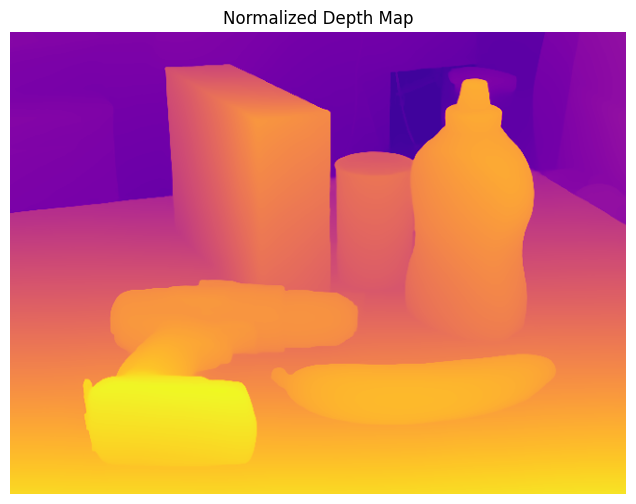

Saved enhanced visualization to 'scene_depth.png'


In [7]:
import cv2
import matplotlib.pyplot as plt

# Print min/max depth
print("Depth stats → min:", depth.min(), ", max:", depth.max())

# Normalize for visualization
depth_vis = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)  # avoid division by 0

# Show using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(depth_vis, cmap="plasma")  # or 'inferno', 'magma', 'viridis'
plt.title("Normalized Depth Map")
plt.axis("off")
plt.show()

# Save enhanced visualization
depth_vis_uint8 = (depth_vis.cpu().numpy() * 255).astype(np.uint8)
cv2.imwrite("scene_depth.png", depth_vis_uint8)
print("Saved enhanced visualization to 'scene_depth.png'")

In [8]:
import cv2
import numpy as np
from PIL import Image

def segment_with_mask(image_path, mask_path):
    img = cv2.imread(image_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    rgb_masked = rgb.copy()
    rgb_masked[mask == 0] = 0
    ys, xs = np.where(mask > 0)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    crop = rgb_masked[y0:y1, x0:x1]
    bbox = [x0, y0, x1-x0, y1-y0]
    return crop, bbox

crop, bbox = segment_with_mask("scene_rgb.jpeg", "masks/mask_01.png")
Image.fromarray(crop).save("scene_crop.png")
print("Cropped object saved to scene_crop.png, bbox:", bbox)

Cropped object saved to scene_crop.png, bbox: [76, 58, 279, 393]


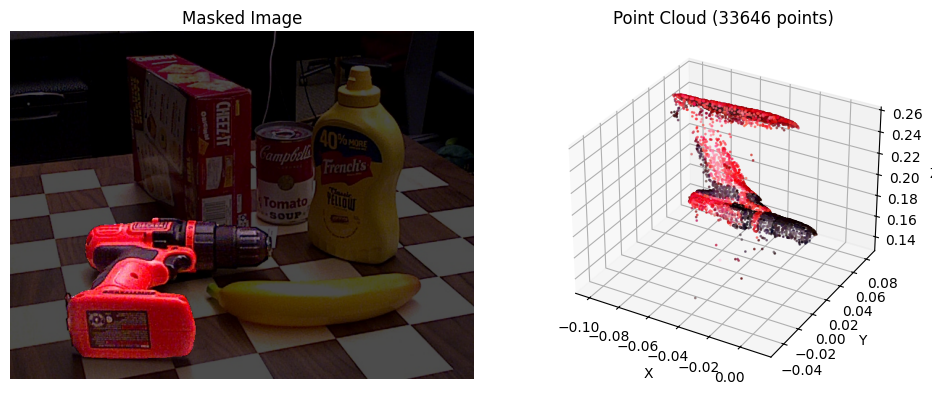

Masked point cloud saved to scene_pc.ply with 33646 points


In [10]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def depth_to_point_cloud_with_mask(depth_path, color_path, mask_path, intrinsics):
    """
    Convert depth image to point cloud and apply mask to extract only object points
    """
    # Load depth, color, and mask
    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED).astype(np.float32) / 1000.0
    color = cv2.cvtColor(cv2.imread(color_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply mask to depth - set masked out regions to 0
    depth_masked = depth.copy()
    depth_masked[mask == 0] = 0
    
    h, w = depth_masked.shape
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    # Camera intrinsics
    fx, fy = intrinsics[0,0], intrinsics[1,1]
    cx, cy = intrinsics[0,2], intrinsics[1,2]
    
    # Convert to 3D points
    z = depth_masked
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    
    # Filter valid points (depth > 0 and within reasonable range)
    valid = (z > 0) & (z < 5.0) & (mask > 0)
    
    pts = np.stack([x[valid], y[valid], z[valid]], axis=-1)
    cols = color[valid] / 255.0
    
    # Create point cloud
    pc = o3d.geometry.PointCloud()
    pc.points = o3d.utility.Vector3dVector(pts)
    pc.colors = o3d.utility.Vector3dVector(cols)
    
    # Simple visualization
    fig = plt.figure(figsize=(10, 4))
    
    # Show original image with mask overlay
    ax1 = fig.add_subplot(121)
    masked_img = color.copy()
    masked_img[mask == 0] = masked_img[mask == 0] * 0.3  # Darken non-masked areas
    ax1.imshow(masked_img)
    ax1.set_title('Masked Image')
    ax1.axis('off')
    
    # Show 3D point cloud
    ax2 = fig.add_subplot(122, projection='3d')
    if len(pts) > 0:
        # Subsample for visualization if too many points
        if len(pts) > 5000:
            indices = np.random.choice(len(pts), 5000, replace=False)
            pts_vis = pts[indices]
            cols_vis = cols[indices]
        else:
            pts_vis = pts
            cols_vis = cols
        
        ax2.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], 
                   c=cols_vis, s=1, alpha=0.6)
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.set_zlabel('Z')
        ax2.set_title(f'Point Cloud ({len(pts)} points)')
    else:
        ax2.text(0.5, 0.5, 0.5, 'No valid points', ha='center', va='center')
        ax2.set_title('Point Cloud (No points)')
    
    plt.tight_layout()
    plt.show()
    
    return pc

# Example intrinsics (replace with your actual camera parameters)
intr = np.array([[575.0, 0, 320.0],
                 [0, 575.0, 240.0],
                 [0,   0,     1.0]])

# Generate point cloud from masked depth
pc = depth_to_point_cloud_with_mask("scene_depth.png", "scene_rgb.jpeg", "masks/mask_01.png", intr)
o3d.io.write_point_cloud("scene_pc.ply", pc)
print(f"Masked point cloud saved to scene_pc.ply with {len(pc.points)} points")

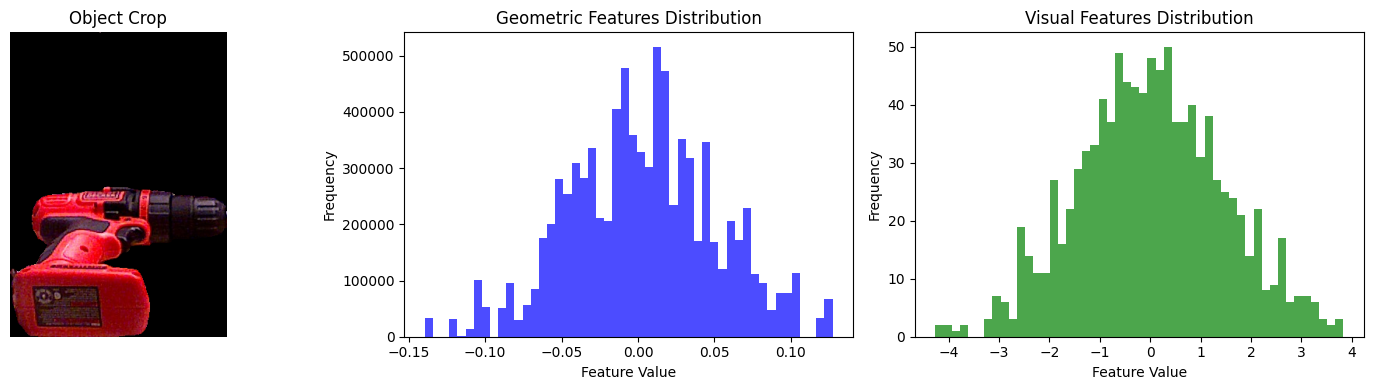

Visual features shape: (1024,)
Geometric features shape: (33646, 256)
Lifted visual features shape: (33646, 1024)


In [12]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

def extract_visual_features(image_crop):
    """Extract visual features using DINOV2"""
    if isinstance(image_crop, np.ndarray):
        im = Image.fromarray(image_crop)
    else:
        im = image_crop
    
    inp = dinov2_transform(im).unsqueeze(0).to(device)
    with torch.no_grad():
        features = dinov2(inp)
    return features.cpu().numpy().squeeze()

def extract_geometric_features(point_cloud):
    """Extract geometric features using PREDATOR-style extractor"""
    if isinstance(point_cloud, o3d.geometry.PointCloud):
        pts = np.asarray(point_cloud.points)
    else:
        pts = point_cloud
    
    # Subsample if too many points
    if len(pts) > 8192:
        indices = np.random.choice(len(pts), 8192, replace=False)
        pts_sampled = pts[indices]
    else:
        pts_sampled = pts
        indices = np.arange(len(pts))
    
    # Convert to tensor and extract features
    pts_tensor = torch.from_numpy(pts_sampled).float().to(device)
    with torch.no_grad():
        geo_features = pred_extractor(pts_tensor).cpu().numpy()
    
    # Expand features back to original point cloud size if needed
    if len(pts) > len(pts_sampled):
        # Simple expansion - repeat features for non-sampled points
        full_features = np.zeros((len(pts), geo_features.shape[1]))
        full_features[indices] = geo_features
        # Fill remaining with nearest neighbor features
        for i in range(len(pts)):
            if i not in indices:
                distances = np.linalg.norm(pts[i] - pts_sampled, axis=1)
                nearest_idx = np.argmin(distances)
                full_features[i] = geo_features[nearest_idx]
        geo_features = full_features
    
    return geo_features, pts

def lift_2d_to_3d_features(visual_feat, points_3d):
    """Lift 2D visual features to 3D points"""
    # Simple approach: broadcast visual features to all 3D points
    num_points = len(points_3d)
    vis_feat_flat = visual_feat.flatten()
    lifted_features = np.tile(vis_feat_flat, (num_points, 1))
    return lifted_features

# Extract features from scene
crop = cv2.imread("scene_crop.png")[:,:,::-1]  # BGR to RGB
vis_feat = extract_visual_features(crop)
geo_feat, geo_pts = extract_geometric_features(pc)
lifted_vis_feat = lift_2d_to_3d_features(vis_feat, geo_pts)

# Simple feature visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Show crop
axes[0].imshow(crop)
axes[0].set_title('Object Crop')
axes[0].axis('off')

# Show feature distributions
axes[1].hist(geo_feat.flatten(), bins=50, alpha=0.7, color='blue', label='Geometric')
axes[1].set_title('Geometric Features Distribution')
axes[1].set_xlabel('Feature Value')
axes[1].set_ylabel('Frequency')

axes[2].hist(vis_feat.flatten(), bins=50, alpha=0.7, color='green', label='Visual')
axes[2].set_title('Visual Features Distribution')
axes[2].set_xlabel('Feature Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Visual features shape: {vis_feat.shape}")
print(f"Geometric features shape: {geo_feat.shape}")
print(f"Lifted visual features shape: {lifted_vis_feat.shape}")

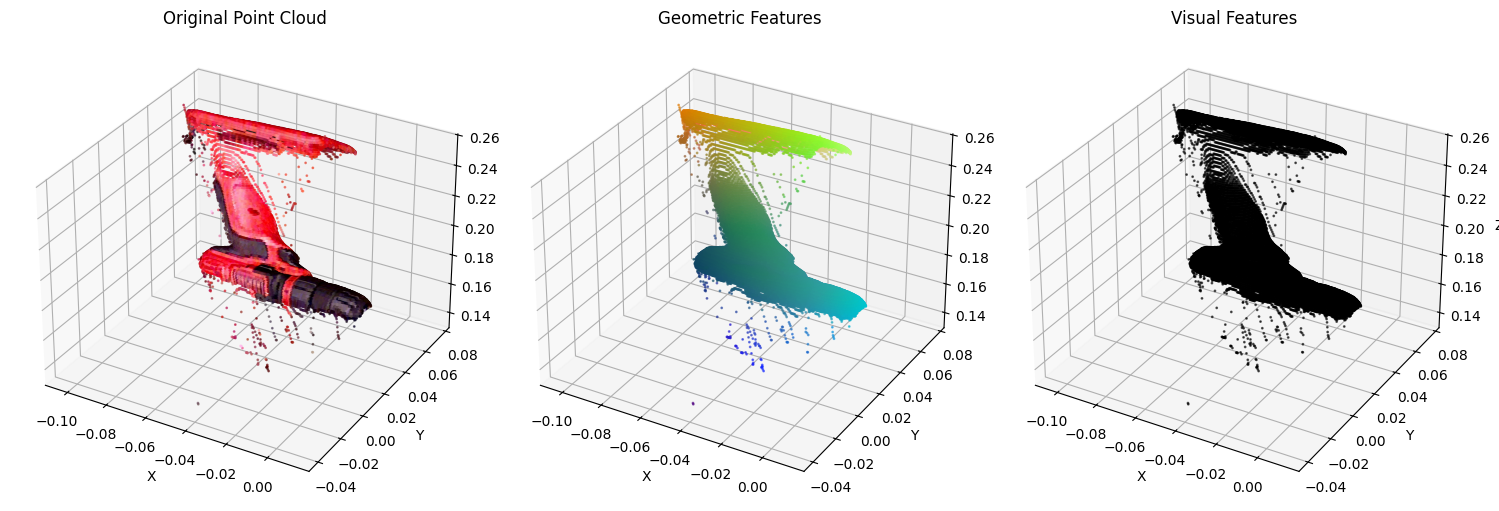

Dual point clouds created and saved:
  - Geometric: scene_geo.ply (33646 points)
  - Visual: scene_vis.ply (33646 points)
  - Feature dimensions: Geo=256, Vis=1024


In [13]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def create_dual_point_clouds_with_viz(point_cloud, geo_features, vis_features):
    """Create dual point clouds and visualize them"""
    if isinstance(point_cloud, o3d.geometry.PointCloud):
        points = np.asarray(point_cloud.points)
        original_colors = np.asarray(point_cloud.colors) if point_cloud.has_colors() else None
    else:
        points = point_cloud
        original_colors = None
    
    # Create geometric point cloud
    pc_geo = o3d.geometry.PointCloud()
    pc_geo.points = o3d.utility.Vector3dVector(points)
    
    # Create visual point cloud
    pc_vis = o3d.geometry.PointCloud()
    pc_vis.points = o3d.utility.Vector3dVector(points)
    
    # Use first 3 dimensions of features as colors for visualization
    def normalize_features_to_colors(features):
        if features.shape[1] >= 3:
            colors = features[:, :3]
        else:
            # If less than 3 dimensions, pad with zeros
            colors = np.zeros((features.shape[0], 3))
            colors[:, :features.shape[1]] = features
        
        # Normalize to [0, 1] range
        colors = colors - colors.min(axis=0)
        colors = colors / (colors.max(axis=0) + 1e-8)
        return colors
    
    geo_colors = normalize_features_to_colors(geo_features)
    vis_colors = normalize_features_to_colors(vis_features)
    
    pc_geo.colors = o3d.utility.Vector3dVector(geo_colors)
    pc_vis.colors = o3d.utility.Vector3dVector(vis_colors)
    
    # Simple dual visualization
    fig = plt.figure(figsize=(15, 5))
    
    # Original point cloud
    ax1 = fig.add_subplot(131, projection='3d')
    if original_colors is not None:
        ax1.scatter(points[:, 0], points[:, 1], points[:, 2], 
                   c=original_colors, s=1, alpha=0.6)
    else:
        ax1.scatter(points[:, 0], points[:, 1], points[:, 2], 
                   c=points[:, 2], cmap='viridis', s=1, alpha=0.6)
    ax1.set_title('Original Point Cloud')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    
    # Geometric features point cloud
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(points[:, 0], points[:, 1], points[:, 2], 
               c=geo_colors, s=1, alpha=0.6)
    ax2.set_title('Geometric Features')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    
    # Visual features point cloud
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(points[:, 0], points[:, 1], points[:, 2], 
               c=vis_colors, s=1, alpha=0.6)
    ax3.set_title('Visual Features')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_zlabel('Z')
    
    # Sync axes for better comparison
    all_points = points
    max_range = np.array([
        all_points[:, 0].max() - all_points[:, 0].min(),
        all_points[:, 1].max() - all_points[:, 1].min(),
        all_points[:, 2].max() - all_points[:, 2].min()
    ]).max() / 2.0
    
    mid_x = (all_points[:, 0].max() + all_points[:, 0].min()) * 0.5
    mid_y = (all_points[:, 1].max() + all_points[:, 1].min()) * 0.5
    mid_z = (all_points[:, 2].max() + all_points[:, 2].min()) * 0.5
    
    for ax in [ax1, ax2, ax3]:
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.tight_layout()
    plt.show()
    
    return pc_geo, pc_vis, geo_features, vis_features

# Create dual point clouds with integrated visualization
pc_geo, pc_vis, final_geo_feat, final_vis_feat = create_dual_point_clouds_with_viz(
    pc, geo_feat, lifted_vis_feat
)

# Save point clouds
o3d.io.write_point_cloud("scene_geo.ply", pc_geo)
o3d.io.write_point_cloud("scene_vis.ply", pc_vis)

print("Dual point clouds created and saved:")
print(f"  - Geometric: scene_geo.ply ({len(pc_geo.points)} points)")
print(f"  - Visual: scene_vis.ply ({len(pc_vis.points)} points)")
print(f"  - Feature dimensions: Geo={final_geo_feat.shape[1]}, Vis={final_vis_feat.shape[1]}")